# Training a REINFORCE racing agent

This notebook presents the project-owned REINFORCE implementation on the continuous-control car-racing problem. It deliberately uses `agents/reinforce.py` and the readable loop in `training/engines/reinforce.py`; the experiment-oriented shared engine is not involved.

The equations and boundary conventions summarized here come from [`docs/LEARNING.md`](../docs/LEARNING.md). The environment state, reward, and circuit representation are specified in [`docs/MDP.md`](../docs/MDP.md) and [`docs/TRACK.md`](../docs/TRACK.md).

## What REINFORCE does in this project

The actor receives a normalized Frenet observation and parametrizes a Gaussian distribution over an unbounded action $U_t$. The environment action is $A_t=\tanh(U_t)$, which keeps throttle and steering inside $[-1,1]$. The agent owns the corrected log-probability calculation for this bounded policy.

REINFORCE has no critic and therefore no bootstrap value. It waits for complete trajectories. For each trajectory it computes return-to-go backwards, with both termination and time-limit truncation acting as episode boundaries:

$$G_t = R_{t+1} + \gamma G_{t+1}.$$

Returns are standardized once across every transition in the collected episode batch. The loss is a sum over each trajectory and then an average over trajectories. The default project configuration updates after eight complete episodes.

## Configuration

All choices used by this demonstration are visible below. They are educational settings, not reported-experiment settings. Set `TRAIN_ON_MULTIPLE_CIRCUITS` to choose between the single seed and the tuple of circuit seeds. When several circuits are enabled, the engine selects one at every episode boundary using a random stream independent from policy sampling and environment resets.

In [10]:
import sys
import time
import warnings
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module="pygame.pkgdata",
)

from agents import ReinforceAgent
from configs import (
    MEDIUM_ACTOR_CONFIG,
    EnvironmentConfig,
    ExecutionConfig,
    ObservationNormalizationConfig,
    ReinforceConfig,
)
from envs.racing import RacingEnv
from envs.tracks import TrackWithGeometry
from training.engines.reinforce import ReinforceTrainingEngine
from training.normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

# Reproducibility and execution
ROOT_SEED = 0
DEVICE = "cpu"  # "cpu" or "cuda"
TRAINING_EPISODES = 6400

# Circuit choice
TRAIN_ON_MULTIPLE_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0
MULTIPLE_CIRCUIT_SEEDS = (0, 1, 2)

# Actor and REINFORCE choices
ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=3e-4)
REINFORCE_CONFIG = ReinforceConfig(
    discount=0.9995,
    completed_episodes_per_update=8,
)
ENVIRONMENT_CONFIG = EnvironmentConfig()
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

# Live rendered rollouts
RENDER_CIRCUIT_INDEX = 0
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"  # "inline" or "window"
LIVE_RENDER_MAX_STEPS = 300
LIVE_FRAME_DELAY = 0.01

torch.cuda.is_available()

True

## Build circuits, random streams, agent, and engine

The circuit seeds are explicit. A single root identity derives separate generators for actor initialization, policy action sampling, environment resets, and training-circuit selection, following the seed contract in `docs/LEARNING.md`. The normalizer updates only when an observation is a current training input.

In [11]:
execution_config = ExecutionConfig(device=DEVICE)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)

circuit_seeds = (
    MULTIPLE_CIRCUIT_SEEDS if TRAIN_ON_MULTIPLE_CIRCUITS else (SINGLE_CIRCUIT_SEED,)
)
tracks = tuple(
    TrackWithGeometry.generate(
        seed,
        track_config=ENVIRONMENT_CONFIG.track,
        vehicle_config=ENVIRONMENT_CONFIG.vehicle,
    )
    for seed in circuit_seeds
)

probe_environment = RacingEnv(tracks[0], config=ENVIRONMENT_CONFIG)
observation_dimensions = probe_environment.observation_space.shape[0]
probe_environment.close()

agent = ReinforceAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    config=REINFORCE_CONFIG,
    initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION, device=DEVICE
    ),
    sampling_generator=streams.get_torch_generator(
        SeedStream.POLICY_ACTION_SAMPLING, device=DEVICE
    ),
    device=DEVICE,
)
normalizer = RunningObservationNormalizer(observation_dimensions, NORMALIZATION_CONFIG)
engine = ReinforceTrainingEngine(
    agent=agent,
    tracks=tracks,
    environment_config=ENVIRONMENT_CONFIG,
    normalizer=normalizer,
    environment_reset_generator=streams.get_numpy_generator(
        SeedStream.ENVIRONMENT_RESETS
    ),
    track_selection_generator=streams.get_numpy_generator(
        SeedStream.TRAINING_TRACK_SELECTION
    ),
)

print(f"Circuits used for training: {circuit_seeds}")
print(f"Observation dimensions: {observation_dimensions}")
print(f"Actor parameters: {agent.actor_parameter_count:,}")

Circuits used for training: (0,)
Observation dimensions: 4
Actor parameters: 4,612


## The policy before training

Evaluation uses the deterministic bounded mean action and frozen normalization statistics. The viewer updates after every environment step, so it shows the initial actor actively interacting without consuming the policy-sampling stream used for training. Use `VIEWER_MODE = "window"` if your notebook frontend does not animate inline output.

In [12]:
def watch_rendered_rollout(title, track):
    if VIEWER_MODE not in {"inline", "window"}:
        raise ValueError("VIEWER_MODE must be 'inline' or 'window'.")

    render_mode = "rgb_array" if VIEWER_MODE == "inline" else "human"
    environment = RacingEnv(track, config=ENVIRONMENT_CONFIG, render_mode=render_mode)
    observation, info = environment.reset(seed=RENDER_RESET_SEED)
    total_return = 0.0
    figure = None

    if VIEWER_MODE == "inline":
        figure, axis = plt.subplots(figsize=(7, 7))
        image = axis.imshow(environment.render())
        axis.axis("off")
        display_handle = display(figure, display_id=True)
    else:
        environment.render()

    try:
        for step in range(1, LIVE_RENDER_MAX_STEPS + 1):
            normalized_observation = normalizer.normalize(observation)
            action = agent.deterministic_action(normalized_observation)
            observation, reward, terminated, truncated, info = environment.step(action)
            total_return += float(reward)

            if VIEWER_MODE == "inline":
                image.set_data(environment.render())
                axis.set_title(f"{title} | step {step} | return {total_return:.2f}")
                display_handle.update(figure)
            else:
                environment.render()
            time.sleep(LIVE_FRAME_DELAY)
            if terminated or truncated:
                break
    finally:
        environment.close()
        if figure is not None:
            plt.close(figure)

    return {
        "interactions": step,
        "return": total_return,
        "collision": bool(info["collision"]),
        "lap_completed": bool(info["lap_completed"]),
        "progress": float(info["episode_progress"]) / track.track.track_length,
    }

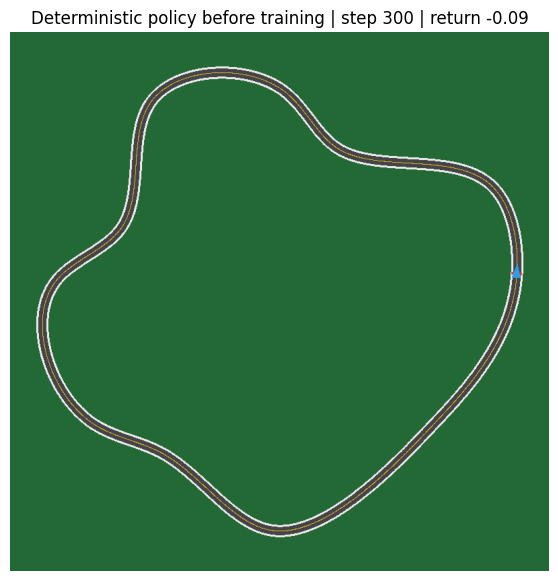

{'interactions': 300,
 'return': -0.08892291780115615,
 'collision': False,
 'lap_completed': False,
 'progress': 0.0010770821988438611}

In [4]:
initial_rollout = watch_rendered_rollout(
    "Deterministic policy before training", tracks[RENDER_CIRCUIT_INDEX]
)
initial_rollout

## Train

The educational engine now performs the complete loop directly: update and normalize the current observation, sample a bounded action, step the environment, and store the detached transition. At an episode boundary it stores a separate trajectory. Once the batch contains `completed_episodes_per_update` trajectories, `ReinforceAgent.update` computes return-to-go, standardizes the returns, forms the documented loss, and applies one optimizer step.

In [ ]:
history = engine.train(TRAINING_EPISODES)

print(f"Episodes collected: {len(history.episodes)}")
print(f"Training interactions: {history.training_interactions}")
print(f"Optimizer updates: {len(history.updates)}")
print(f"Unused complete trajectories: {TRAINING_EPISODES % agent.collection_size}")

Training episodes:   0%|          | 0/6400 [00:00<?, ?episode/s]

## Inspect the collected records

Episode records show the circuit, outcome, return, interaction count, progress, mean speed, and mean throttle magnitude. The last two signals help distinguish forward driving from policies that remain slow or repeatedly switch between throttle and braking. Update records show exactly when an optimizer update occurred, how many transitions it used, and the diagnostics returned by the agent. These are the records produced by the readable engine itself.

In [6]:
episode_rows = []
for record in history.episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    episode_rows.append(row)

update_rows = [asdict(record) for record in history.updates]

print("First five episode records:")
for row in episode_rows[:5]:
    print(row)

print("\nLast five episode records:")
for row in episode_rows[-5:]:
    print(row)

print("\nFirst three update records:")
for row in update_rows[:3]:
    print(row)

First five episode records:
{'episode_index': 0, 'circuit_identity': '0', 'interactions': 435, 'undiscounted_return': -20.101329350825637, 'outcome': 'crashed', 'final_progress': 0.028905853747699696, 'maximum_progress': 0.028905853747699696, 'mean_speed': 2.8881846835650773, 'mean_throttle_magnitude': 0.4036617930135529}
{'episode_index': 1, 'circuit_identity': '0', 'interactions': 787, 'undiscounted_return': -20.182812069473066, 'outcome': 'crashed', 'final_progress': 0.05313526403373199, 'maximum_progress': 0.05313526403373199, 'mean_speed': 2.910865277805741, 'mean_throttle_magnitude': 0.3935121209374712}
{'episode_index': 2, 'circuit_identity': '0', 'interactions': 589, 'undiscounted_return': -20.156676714748308, 'outcome': 'crashed', 'final_progress': 0.019731543746337756, 'maximum_progress': 0.019731543746337756, 'mean_speed': 1.4724084080619095, 'mean_throttle_magnitude': 0.3851496838399344}
{'episode_index': 3, 'circuit_identity': '0', 'interactions': 443, 'undiscounted_return

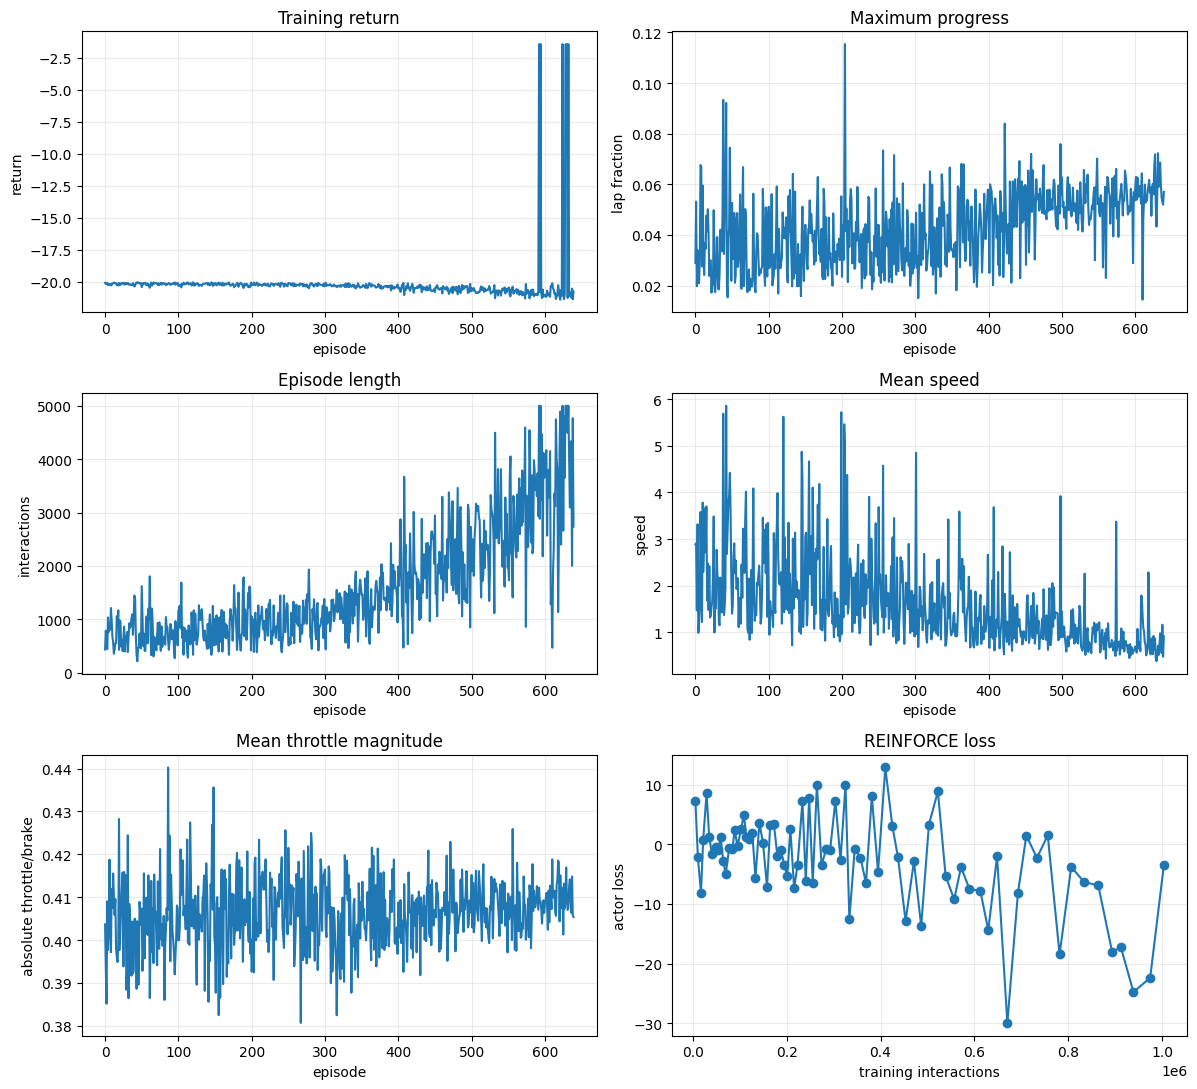

In [7]:
episode_indices = np.asarray([row["episode_index"] for row in episode_rows])
returns = np.asarray([row["undiscounted_return"] for row in episode_rows])
progress = np.asarray([row["maximum_progress"] for row in episode_rows])
lengths = np.asarray([row["interactions"] for row in episode_rows])
mean_speeds = np.asarray([row["mean_speed"] for row in episode_rows])
mean_throttle_magnitudes = np.asarray(
    [row["mean_throttle_magnitude"] for row in episode_rows]
)
update_interactions = np.asarray([row["training_interactions"] for row in update_rows])
actor_losses = np.asarray([row["diagnostics"]["actor_loss"] for row in update_rows])

figure, axes = plt.subplots(3, 2, figsize=(12, 11))
axes[0, 0].plot(episode_indices, returns)
axes[0, 0].set(title="Training return", xlabel="episode", ylabel="return")
axes[0, 1].plot(episode_indices, progress)
axes[0, 1].set(title="Maximum progress", xlabel="episode", ylabel="lap fraction")
axes[1, 0].plot(episode_indices, lengths)
axes[1, 0].set(title="Episode length", xlabel="episode", ylabel="interactions")
axes[1, 1].plot(episode_indices, mean_speeds)
axes[1, 1].set(title="Mean speed", xlabel="episode", ylabel="speed")
axes[2, 0].plot(episode_indices, mean_throttle_magnitudes)
axes[2, 0].set(
    title="Mean throttle magnitude",
    xlabel="episode",
    ylabel="absolute throttle/brake",
)
axes[2, 1].plot(update_interactions, actor_losses, marker="o")
axes[2, 1].set(
    title="REINFORCE loss", xlabel="training interactions", ylabel="actor loss"
)
for axis in axes.flat:
    axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## The policy after training

The final live rollout uses the same circuit, reset seed, deterministic action rule, and frozen normalizer as the initial view. This makes the visual comparison about the policy and the training-updated normalization state rather than exploration noise.

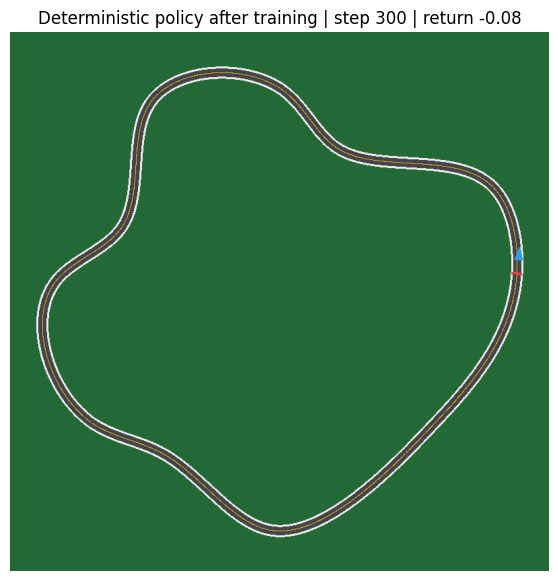

After training:  {'interactions': 300, 'return': -0.07729306531270697, 'collision': False, 'lap_completed': False, 'progress': 0.012706934687292903}


In [8]:
final_rollout = watch_rendered_rollout(
    "Deterministic policy after training", tracks[RENDER_CIRCUIT_INDEX]
)
# print("Before training:", initial_rollout)
print("After training: ", final_rollout)